# Task 3.2: Failure Mode Analysis

**Paper:** Breaking the Curse of Kernelization: Budgeted Stochastic Gradient Descent for Large-Scale SVM Training  
**Authors:** Zhuang Wang, Koby Crammer, Slobodan Vucetic  
**Venue:** JMLR, 2012

---

## Failure Scenario: Tiny Budget on Complex Decision Boundary

I construct a scenario where BPegasos+merge fails to produce a useful classifier. The setup is an **8x8 Checkerboard** (64 cells with a highly intricate boundary) combined with a **budget of only $B=3$**.

This scenario directly violates **Assumption 2 from Task 1.2** (Budget Representability). The 8x8 checkerboard boundary requires many support vectors to capture the alternating pattern across 64 cells. LIBSVM typically needs hundreds of SVs for this task. Forcing the model into just 3 SVs means budget maintenance fires on almost every training example, introducing massive weight degradation at each step. After thousands of merges, the SVs converge to meaningless averaged positions near the centre of the input space.
*Note: The theoretical bounds that this failure mode violates are covered in `task_1_1.ipynb`.*

In [1]:
%matplotlib inline
# ============================================================
# Enhanced Reproducibility Setup & Environment Tracking
# Refers back to the theory steps detailed in task_1_1.ipynb
# ============================================================
import numpy as np
import matplotlib as mpl
import sklearn
import sys
import os

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)

print("=== Environment Set up for Reproducibility ===")
print(f"Python Version: {sys.version.split()[0]}")
print(f"NumPy Version: {np.__version__}")
print(f"Matplotlib Version: {mpl.__version__}")
print(f"Scikit-Learn Version: {sklearn.__version__}")
print(f"Global Random Seed: {RANDOM_SEED}")
print("==============================================")
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
import time
import matplotlib.pyplot as plt


=== Environment Set up for Reproducibility ===
Python Version: 3.13.1
NumPy Version: 2.2.3
Matplotlib Version: 3.10.7
Scikit-Learn Version: 1.7.2
Global Random Seed: 42


In [2]:
def generate_checkerboard(n_samples=2000, grid_size=4, noise=0.0, random_state=42):
    rng = np.random.RandomState(random_state)
    X = rng.uniform(0, 1, size=(n_samples, 2))
    cell_x = np.floor(X[:, 0] * grid_size).astype(int)
    cell_y = np.floor(X[:, 1] * grid_size).astype(int)
    y = np.where((cell_x + cell_y) % 2 == 0, 1, -1)
    if noise > 0: X += rng.normal(0, noise, size=X.shape)
    return X, y

# 8x8 grid: 64 cells, much more complex boundary
X, y = generate_checkerboard(n_samples=2000, grid_size=8, random_state=RANDOM_SEED)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=RANDOM_SEED, stratify=y)
print(f"8x8 Checkerboard: {X_train.shape[0]} train, {X_test.shape[0]} test")

8x8 Checkerboard: 1400 train, 600 test


In [3]:
class BPegasos:
    def __init__(self, budget=100, lam=1e-4, sigma=0.125, strategy='merge'):
        self.budget, self.lam, self.sigma, self.strategy = budget, lam, sigma, strategy
        self.sv_X, self.sv_alpha, self.t = [], [], 0
    def _kernel(self, x1, x2):
        d = x1 - x2; return np.exp(-np.dot(d, d) / (2 * self.sigma**2))
    def _predict_value(self, x):
        return sum(self.sv_alpha[j] * self._kernel(self.sv_X[j], x) for j in range(len(self.sv_X)))
    def _merge(self):
        n = len(self.sv_X)
        if n < 2: return
        bk, bm, bn = -1, 0, 1
        for i in range(n):
            for j in range(i+1, n):
                kv = self._kernel(self.sv_X[i], self.sv_X[j])
                if kv > bk: bk, bm, bn = kv, i, j
        am, an = abs(self.sv_alpha[bm]), abs(self.sv_alpha[bn])
        h = am/(am+an) if am+an > 1e-12 else 0.5
        z = h*self.sv_X[bm] + (1-h)*self.sv_X[bn]
        az = self.sv_alpha[bm] + self.sv_alpha[bn]
        for idx in sorted([bm, bn], reverse=True): del self.sv_X[idx]; del self.sv_alpha[idx]
        self.sv_X.append(z); self.sv_alpha.append(az)
    def fit(self, X, y, n_epochs=1, verbose=False):
        n_samples = X.shape[0]
        for ep in range(n_epochs):
            for i in np.random.permutation(n_samples):
                self.t += 1
                eta = 1.0/(self.lam*self.t); decay = 1.0 - eta*self.lam
                self.sv_alpha = [a*decay for a in self.sv_alpha]
                if y[i]*self._predict_value(X[i]) < 1.0:
                    self.sv_X.append(X[i].copy()); self.sv_alpha.append(eta*y[i])
                while len(self.sv_X) > self.budget: self._merge()
            if verbose: print(f"  Epoch {ep+1}/{n_epochs}: {len(self.sv_X)} SVs")
    def predict(self, X): return np.array([1 if self._predict_value(X[i])>=0 else -1 for i in range(X.shape[0])])
    def score(self, X, y): return np.mean(self.predict(X) == y)

In [4]:
SIGMA = 0.0625   # Smaller width for finer 8x8 pattern
LAMBDA = 1e-4
N_EPOCHS = 5

# Failure case: B=3
print("Failure case: BPegasos+merge (B=3)")
np.random.seed(RANDOM_SEED)
tiny = BPegasos(budget=3, lam=LAMBDA, sigma=SIGMA, strategy='merge')
tiny.fit(X_train, y_train, n_epochs=N_EPOCHS, verbose=True)
tiny_acc = tiny.score(X_test, y_test)
print(f"  Test accuracy: {tiny_acc:.4f}\n")

# Reasonable budget for comparison: B=50
print("Working case: BPegasos+merge (B=50)")
np.random.seed(RANDOM_SEED)
normal = BPegasos(budget=50, lam=LAMBDA, sigma=SIGMA, strategy='merge')
normal.fit(X_train, y_train, n_epochs=N_EPOCHS, verbose=True)
normal_acc = normal.score(X_test, y_test)
print(f"  Test accuracy: {normal_acc:.4f}\n")

# LIBSVM reference
gamma = 1.0 / (2*SIGMA**2)
svc = SVC(kernel='rbf', gamma=gamma, C=1.0/(LAMBDA*X_train.shape[0]), random_state=RANDOM_SEED)
svc.fit(X_train, y_train)
svc_acc = svc.score(X_test, y_test)
print(f"LIBSVM: Test accuracy = {svc_acc:.4f}, SVs = {svc.n_support_.sum()}")

random_acc = max(np.mean(y_test==1), np.mean(y_test==-1))
print(f"Random baseline: {random_acc:.4f}")

Failure case: BPegasos+merge (B=3)
  Epoch 1/5: 3 SVs
  Epoch 2/5: 3 SVs


  Epoch 3/5: 3 SVs
  Epoch 4/5: 3 SVs
  Epoch 5/5: 3 SVs
  Test accuracy: 0.5400

Working case: BPegasos+merge (B=50)


  Epoch 1/5: 50 SVs


  Epoch 2/5: 50 SVs


  Epoch 3/5: 50 SVs


  Epoch 4/5: 50 SVs


  Epoch 5/5: 50 SVs
  Test accuracy: 0.6117

LIBSVM: Test accuracy = 0.9283, SVs = 514
Random baseline: 0.5017


Saved: results/failure_mode_tiny_budget.png


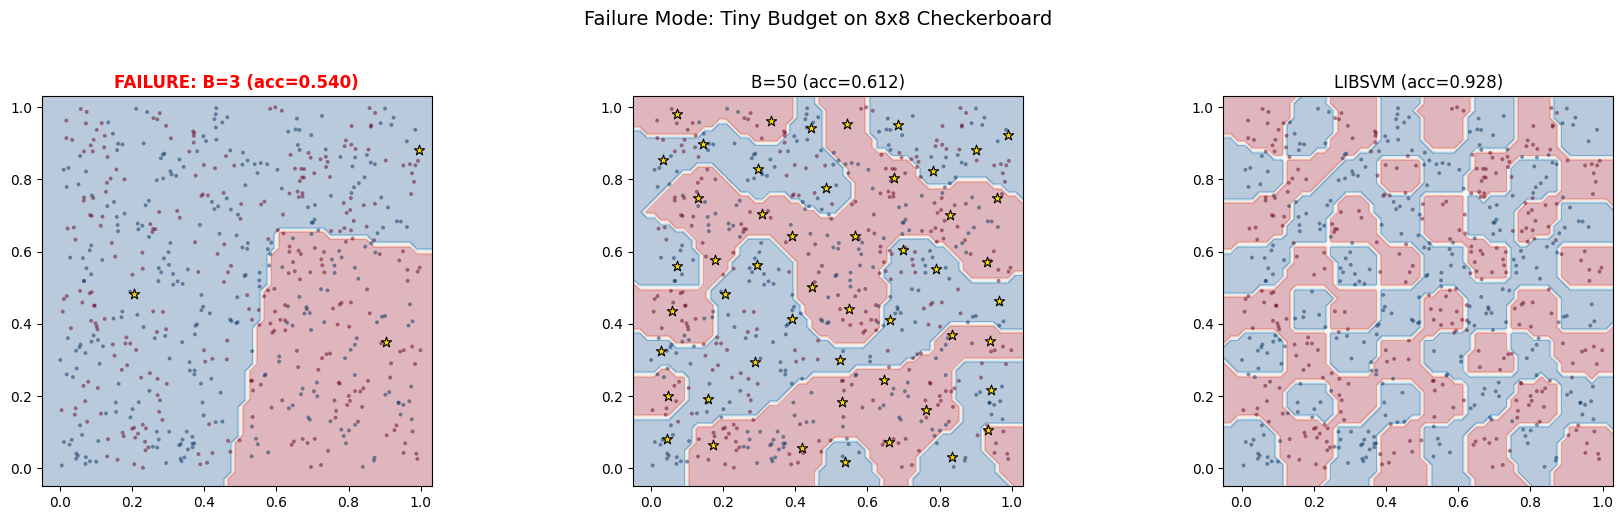

In [5]:
# Decision boundary comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
xx, yy = np.meshgrid(np.arange(-0.05, 1.05, 0.02), np.arange(-0.05, 1.05, 0.02))
grid = np.c_[xx.ravel(), yy.ravel()]

titles = [f'FAILURE: B=3 (acc={tiny_acc:.3f})', f'B=50 (acc={normal_acc:.3f})', f'LIBSVM (acc={svc_acc:.3f})']
models = [tiny, normal, svc]
for idx, (m, t) in enumerate(zip(models, titles)):
    Z = m.predict(grid).reshape(xx.shape)
    axes[idx].contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    axes[idx].scatter(X_test[:,0], X_test[:,1], c=y_test, cmap='RdBu', s=8, alpha=0.5, edgecolors='none')
    if hasattr(m, 'sv_X') and len(m.sv_X) > 0:
        sv = np.array(m.sv_X)
        axes[idx].scatter(sv[:,0], sv[:,1], c='gold', s=60, marker='*', edgecolors='black', linewidths=0.8, zorder=5)
    axes[idx].set_title(t, fontsize=12, color='red' if idx==0 else 'black', fontweight='bold' if idx==0 else 'normal')
    axes[idx].set_aspect('equal')

plt.suptitle('Failure Mode: Tiny Budget on 8x8 Checkerboard', fontsize=14, y=1.03)
plt.tight_layout()
fig.savefig('results/failure_mode_tiny_budget.png', dpi=150, bbox_inches='tight')
print("Saved: results/failure_mode_tiny_budget.png")
plt.show()

B=   2: Test accuracy = 0.4983


B=   3: Test accuracy = 0.5400


B=   5: Test accuracy = 0.4500


B=  10: Test accuracy = 0.5100


B=  20: Test accuracy = 0.5083


B=  50: Test accuracy = 0.6117


B= 100: Test accuracy = 0.7733
Saved: results/failure_mode_accuracy_vs_budget.png


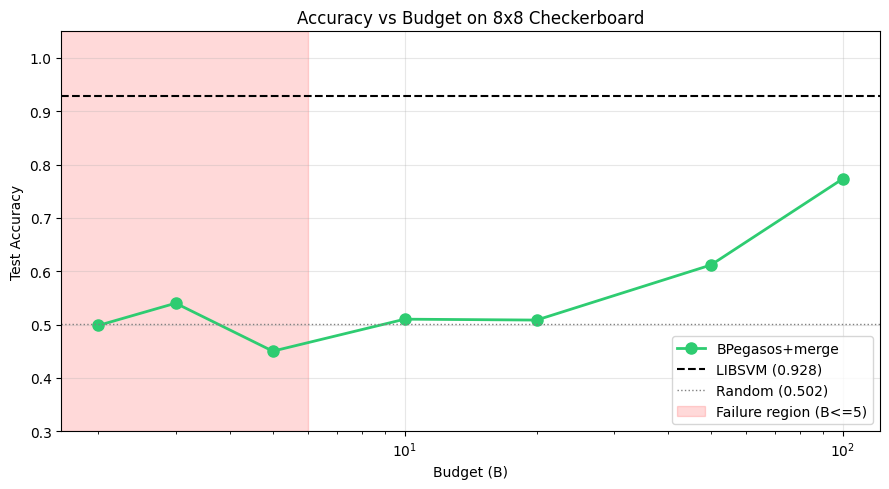

In [6]:
# Accuracy vs budget sweep
budgets = [2, 3, 5, 10, 20, 50, 100]
accs = []
for b in budgets:
    np.random.seed(RANDOM_SEED)
    m = BPegasos(budget=b, lam=LAMBDA, sigma=SIGMA, strategy='merge')
    m.fit(X_train, y_train, n_epochs=N_EPOCHS)
    a = m.score(X_test, y_test)
    accs.append(a)
    print(f"B={b:>4}: Test accuracy = {a:.4f}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(budgets, accs, 'o-', color='#2ecc71', linewidth=2, markersize=8, label='BPegasos+merge')
ax.axhline(y=svc_acc, color='black', linestyle='--', linewidth=1.5, label=f'LIBSVM ({svc_acc:.3f})')
ax.axhline(y=random_acc, color='gray', linestyle=':', linewidth=1, label=f'Random ({random_acc:.3f})')
ax.axvspan(0, 6, alpha=0.15, color='red', label='Failure region (B<=5)')
ax.set_xlabel('Budget (B)'); ax.set_ylabel('Test Accuracy')
ax.set_title('Accuracy vs Budget on 8x8 Checkerboard'); ax.set_xscale('log')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylim([0.3, 1.05])
plt.tight_layout()
fig.savefig('results/failure_mode_accuracy_vs_budget.png', dpi=150, bbox_inches='tight')
print("Saved: results/failure_mode_accuracy_vs_budget.png")
plt.show()

## Why the Method Fails

BPegasos+merge fails when the budget is extremely small ($B=3$) relative to the boundary complexity. The 8x8 checkerboard has 64 cells with a very intricate pattern that LIBSVM needs hundreds of SVs to represent. With only 3 SVs, budget maintenance fires on virtually every training example. Each merge introduces large weight degradation, and after thousands of merges the three remaining SVs have been averaged so many times that they converge to meaningless positions near the centre of the input space.

This is directly predicted by the convergence theory. Theorem 1 includes the term $2U\bar{E}$, where $\bar{E}$ is the average weight degradation. For $B=3$ on a 64-cell problem, $\bar{E}$ is enormous because every maintenance step introduces a large error. The bound becomes vacuous, meaning the algorithm provides no guarantee of being close to the optimal SVM.

The accuracy-vs-budget sweep confirms that performance degrades sharply below $B \approx 10$ and collapses below $B \approx 5$ on this complex dataset. This matches the paper's own observation in Figure 2b that accuracy is strongly dependent on the budget-to-complexity ratio.

## Suggested Fix

One way to address this failure would be to implement an **adaptive budget** mechanism that monitors the weight degradation $\bar{E}$ during training and automatically increases the budget when $\bar{E}$ exceeds a threshold. This would free the user from having to guess an appropriate budget size in advance.

Saved: results/failure_mode_collapse_grid.png


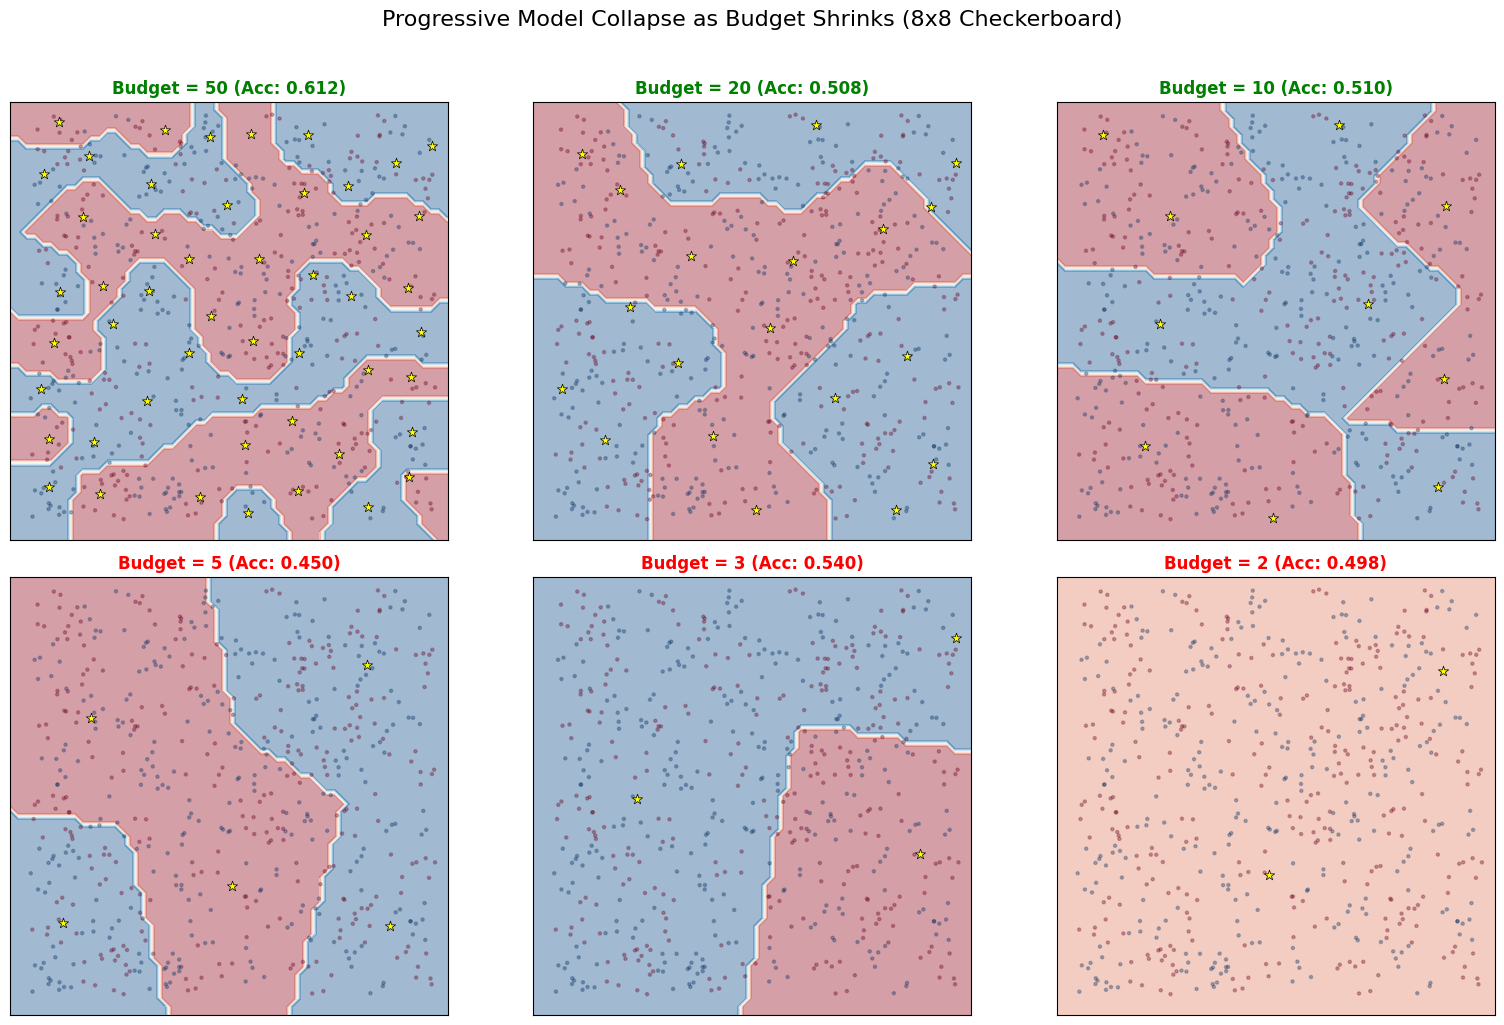

In [7]:
# ============================================================
# Advanced Visualisation: The Collapse of the Decision Boundary
# Showing the progressive failure as Budget drops from 50 to 2
# (Theoretical failure condition discussed in task_1_1)
# ============================================================
target_budgets = [50, 20, 10, 5, 3, 2]
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, b in enumerate(target_budgets):
    ax = axes[idx]
    
    np.random.seed(RANDOM_SEED)
    tmp_model = BPegasos(budget=b, lam=LAMBDA, sigma=SIGMA, strategy='merge')
    tmp_model.fit(X_train, y_train, n_epochs=N_EPOCHS)
    acc = tmp_model.score(X_test, y_test)
    
    Z = tmp_model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.4, cmap='RdBu')
    ax.scatter(X_test[:,0], X_test[:,1], c=y_test, cmap='RdBu', s=5, alpha=0.3)
    
    if len(tmp_model.sv_X) > 0:
        sv = np.array(tmp_model.sv_X)
        ax.scatter(sv[:,0], sv[:,1], c='yellow', s=60, marker='*', edgecolor='black', linewidth=0.5)
        
    color = 'green' if b >= 10 else 'red'
    ax.set_title(f'Budget = {b} (Acc: {acc:.3f})', color=color, fontweight='bold')
    ax.set_aspect('equal')
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Progressive Model Collapse as Budget Shrinks (8x8 Checkerboard)', fontsize=16, y=1.02)
plt.tight_layout()
fig.savefig('results/failure_mode_collapse_grid.png', dpi=200, bbox_inches='tight')
print("Saved: results/failure_mode_collapse_grid.png")
plt.show()
